# Analyse and plot the different projections between versions and options (by just looking at a single CMIP6 GCM)

For comparing the different projection differences, we only use a single GCM (CMIP6 MRI-ESM). 

In [22]:
import pandas as pd
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['figure.figsize'] = (14, 8)

# controls what is stored INSIDE the notebook (the "inline" view)
# keeping this low keeps the .ipynb file size small, and makes it easier to load/view
%config InlineBackend.figure_format = 'jpg' # JPG is much smaller than PNG
plt.rcParams['figure.dpi'] = 75 

In [23]:
cmip = 'CMIP6'
add = '_only_one_gcm'

In [37]:
# IPCC colors from: https://pyam-iamc.readthedocs.io/en/stable/tutorials/ipcc_colors.html
colors_scenario = {# AR6 ssps (from CMIP6)
                    'ssp126': '#003466',
                   #'ssp245':'#f69320',
                    'ssp370':'#df0000',
                   #'ssp434':'#2274ae',
                  'ssp585':'#980002'}
                   # AR5 rcp colors
                  #'rcp26': '#0000FF', 'rcp45':'#79BCFF', 'rcp60':'#FF822D', 'rcp85':'#FF0000',
                  # AR6 rcp colors
d_reg_num_name = {}
d_reg_num_name['01'] = 'Alaska'
d_reg_num_name['02'] = 'Western Canada & USA'
d_reg_num_name['03'] = 'Arctic Canada North'
d_reg_num_name['04'] = 'Arctic Canada South'
d_reg_num_name['05'] = 'Greenland'
d_reg_num_name['06'] = 'Iceland'
d_reg_num_name['07'] = 'Svalbard and Jan Mayen'
d_reg_num_name['08'] = 'Scandinavia'
d_reg_num_name['09'] = 'Russian Arctic'
d_reg_num_name['10'] = 'North Asia'
d_reg_num_name['11'] = 'Central Europe'
d_reg_num_name['12'] = 'Caucasus and Middle East'
d_reg_num_name['13'] = 'Central Asia'
d_reg_num_name['14'] = 'South Asia West'
d_reg_num_name['15'] = 'South Asia East'
d_reg_num_name['16'] = 'Low Latitudes'
d_reg_num_name['17'] = 'Southern Andes'
d_reg_num_name['18'] = 'New Zealand'
d_reg_num_name['19'] = 'Subantarctic & Antarctic Islands'

### Comparing RGI 6.2 to RGI 7.0G projections

In [38]:
# change this path to your local path 
_path = '/home/www/oggm/oggm-standard-projections/oggm-standard-projections-csv-files/1.6.3/'
baseline_climate = 'w5e5'
exp = 'regional_spinup'  # this is actually the same as "match_geod_pergla" (if the dynamic spinup gdirs are used)
## new for OGGM v1.6.3 --> additional experiments
path = _path + f'{baseline_climate}/{exp}/'
ls_d = {'rgi70G':'-',
        'rgi70C':':',
        'rgi62':'--'}
rgi_versions = ['rgi62','rgi70G', 'rgi70C']



In [40]:
from matplotlib.lines import Line2D

scenario_handles = [
    Line2D(
        [0], [0],
        color=colors_scenario[scen],
        lw=3,
        ls='-',
        label=scen
    )
    for scen in sorted(colors_scenario.keys())
]
rgi_handles = [
    Line2D(
        [0], [0],
        color='black',
        lw=3,
        ls=ls_d[rgi_version],
        label=rgi_version
    )
    for rgi_version in rgi_versions
]

In [39]:
import oggm
import geopandas as gpd
rgi_regs = []
for rgi_reg in np.arange(1,20,1):
    if rgi_reg < 10:
        rgi_reg = '0'+str(rgi_reg)
    else:
        rgi_reg = str(rgi_reg)
    rgi_regs.append(rgi_reg)
df_itmix = pd.read_hdf(oggm.utils.get_demo_file('rgi62_itmix_df.h5'))
rgidf_dict = {}
for rgi_reg in rgi_regs:
    path_rgi = oggm.utils.get_rgi_region_file(rgi_reg, version='6')
    rgidf = gpd.read_file(path_rgi)
    # Greenland periphery : all glaciers with connectivity level 0 and 1 should be included, level 2 glaciers should be excluded (as was the case for GlacierMIP2)
    # total RGI area: 89,651km2
    if rgi_reg == '05':
        rgidf = rgidf.loc[(rgidf['Connect'] == 0) | (rgidf['Connect'] ==1)]
    rgidf_dict[rgi_reg] = rgidf
    rgidf_dict[rgi_reg] = rgidf_dict[rgi_reg].set_index('RGIId')
    df_itmix.loc[rgidf.RGIId.values,'rgi_region'] = rgi_reg
# remove 05-connectivity 2 glaciers 
df_itmix = df_itmix.loc[~df_itmix.rgi_region.isna()]

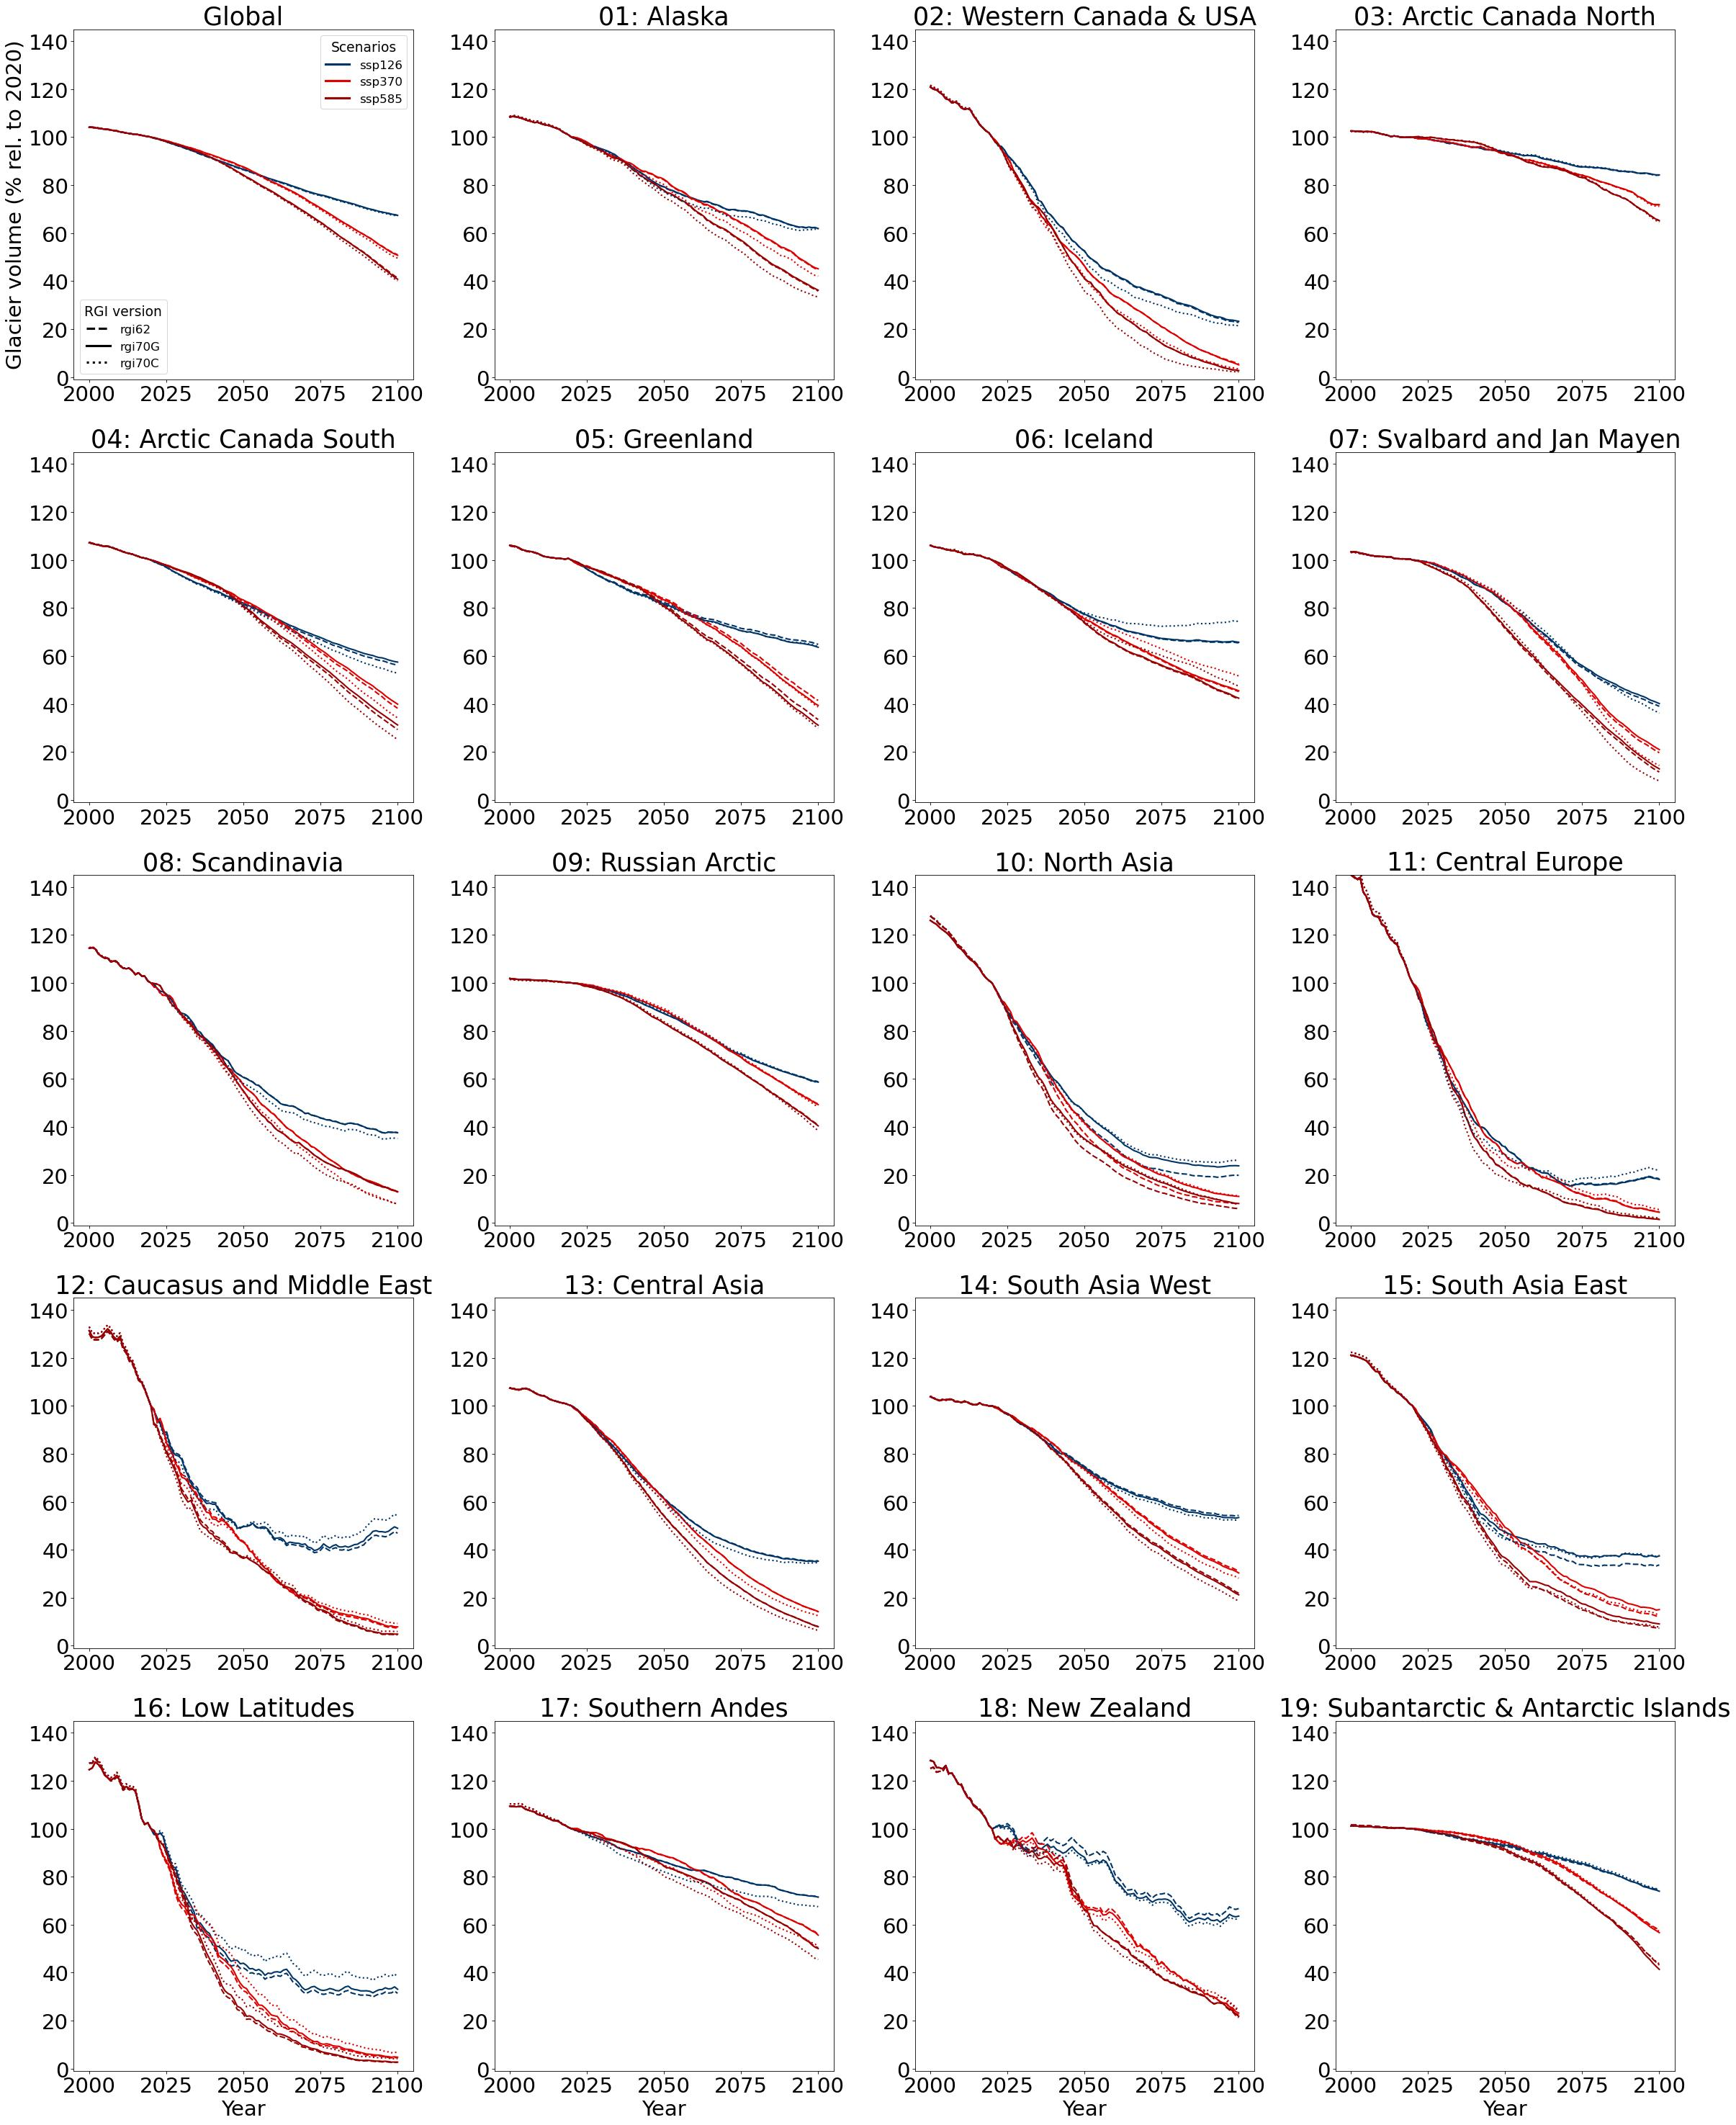

In [54]:

plt.rc('font', size=28)
plt.figure(figsize=(32,40)) #harey=True, sharex=True)
#plt.ylabel('Volume (in % relative to 2020)')

for j,r in enumerate(['Global', 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19]): 
    plt.subplot(5,4,j+1)
    ax = plt.gca()
    for rgi_version in rgi_versions: 
        end_year= 2100
        df_meta = pd.read_csv(f'{path}/common_running_2100/metadata_{rgi_version}{add}.csv')
        df_meta.loc[df_meta.end_year==2101,'end_year'] = 2100

        scenario_list = list(df_meta.loc[(df_meta.cmip==cmip) & (df_meta.end_year==end_year)].scenario.unique())
        scenario_list.sort()
        if r == 'Global':
            rgi_reg = r
            if rgi_version != 'rgi62':
                rgi_reg_l = f'global_{rgi_version}'
            else:
                rgi_reg_l = 'global'
            ax.set_title('Global')
        else:
            rgi_reg = f'{r:02}'
            if rgi_version == 'rgi70G':
                rgi_reg_l = f'RGI2000-v7.0-G-{rgi_reg}'
            elif rgi_version == 'rgi70C':
                rgi_reg_l = f'RGI2000-v7.0-C-{rgi_reg}'                
            else:
                rgi_reg_l = f'RGI{rgi_reg}'
            if rgi_version=='rgi62':
                ax.set_title(f'{rgi_reg}: {d_reg_num_name[rgi_reg]}')
        
        #for end_year in [2100]:
        ls = ls_d[rgi_version]
        # let's only plot those scenarios that exist only until 2300
        scenario_list = list(df_meta.loc[(df_meta.cmip==cmip) & (df_meta.end_year==2100)].scenario.unique())
        scenario_list.sort()

        for scenario in scenario_list:
            idir = path + 'common_running_2100/' + f'volume/{cmip}/{end_year}/{rgi_reg_l}/'

            df = pd.read_csv(idir + f'{scenario}.csv', index_col=0)
            df_rel = 100*df/df.loc[2020]

            #ax.plot(df.index, df_rel.median(axis=1), lw=2, color=colors_scenario[scenario],
            #        label = f'{rgi_version}: {scenario}', # until {end_year} (n={len(df_rel.columns)})',
            #        ls= ls)
            ax.plot(df.index, df_rel, lw=2, alpha = 1, color=colors_scenario[scenario],
                   ls= ls, label = f'{rgi_version}: {scenario}');
            #ax.fill_between(df.index, df_rel.min(axis=1), df_rel.max(axis=1), alpha=0.1, color=colors_scenario[scenario])
    if j in [0]: #4,8,12,16]:
        ax.set_ylabel('Glacier volume (% rel. to 2020)')
    if j>=16:
        ax.set_xlabel('Year')
    if j == 0:
        leg1 = ax.legend(
            handles=scenario_handles,
            title='Scenarios',
            loc='upper right',
            fontsize=16,
            title_fontsize=18
        )
    
        leg2 = ax.legend(
            handles=rgi_handles,
            title='RGI version',
            loc='lower left',
            fontsize=16,
            title_fontsize=18
        )
        ax.add_artist(leg1)
    ax.set_ylim([-1,145])
plt.tight_layout()
plt.savefig('regional_glacier_volume_until2100_relative_comparison_rgi6_vs_7_only_one_gcm.png')

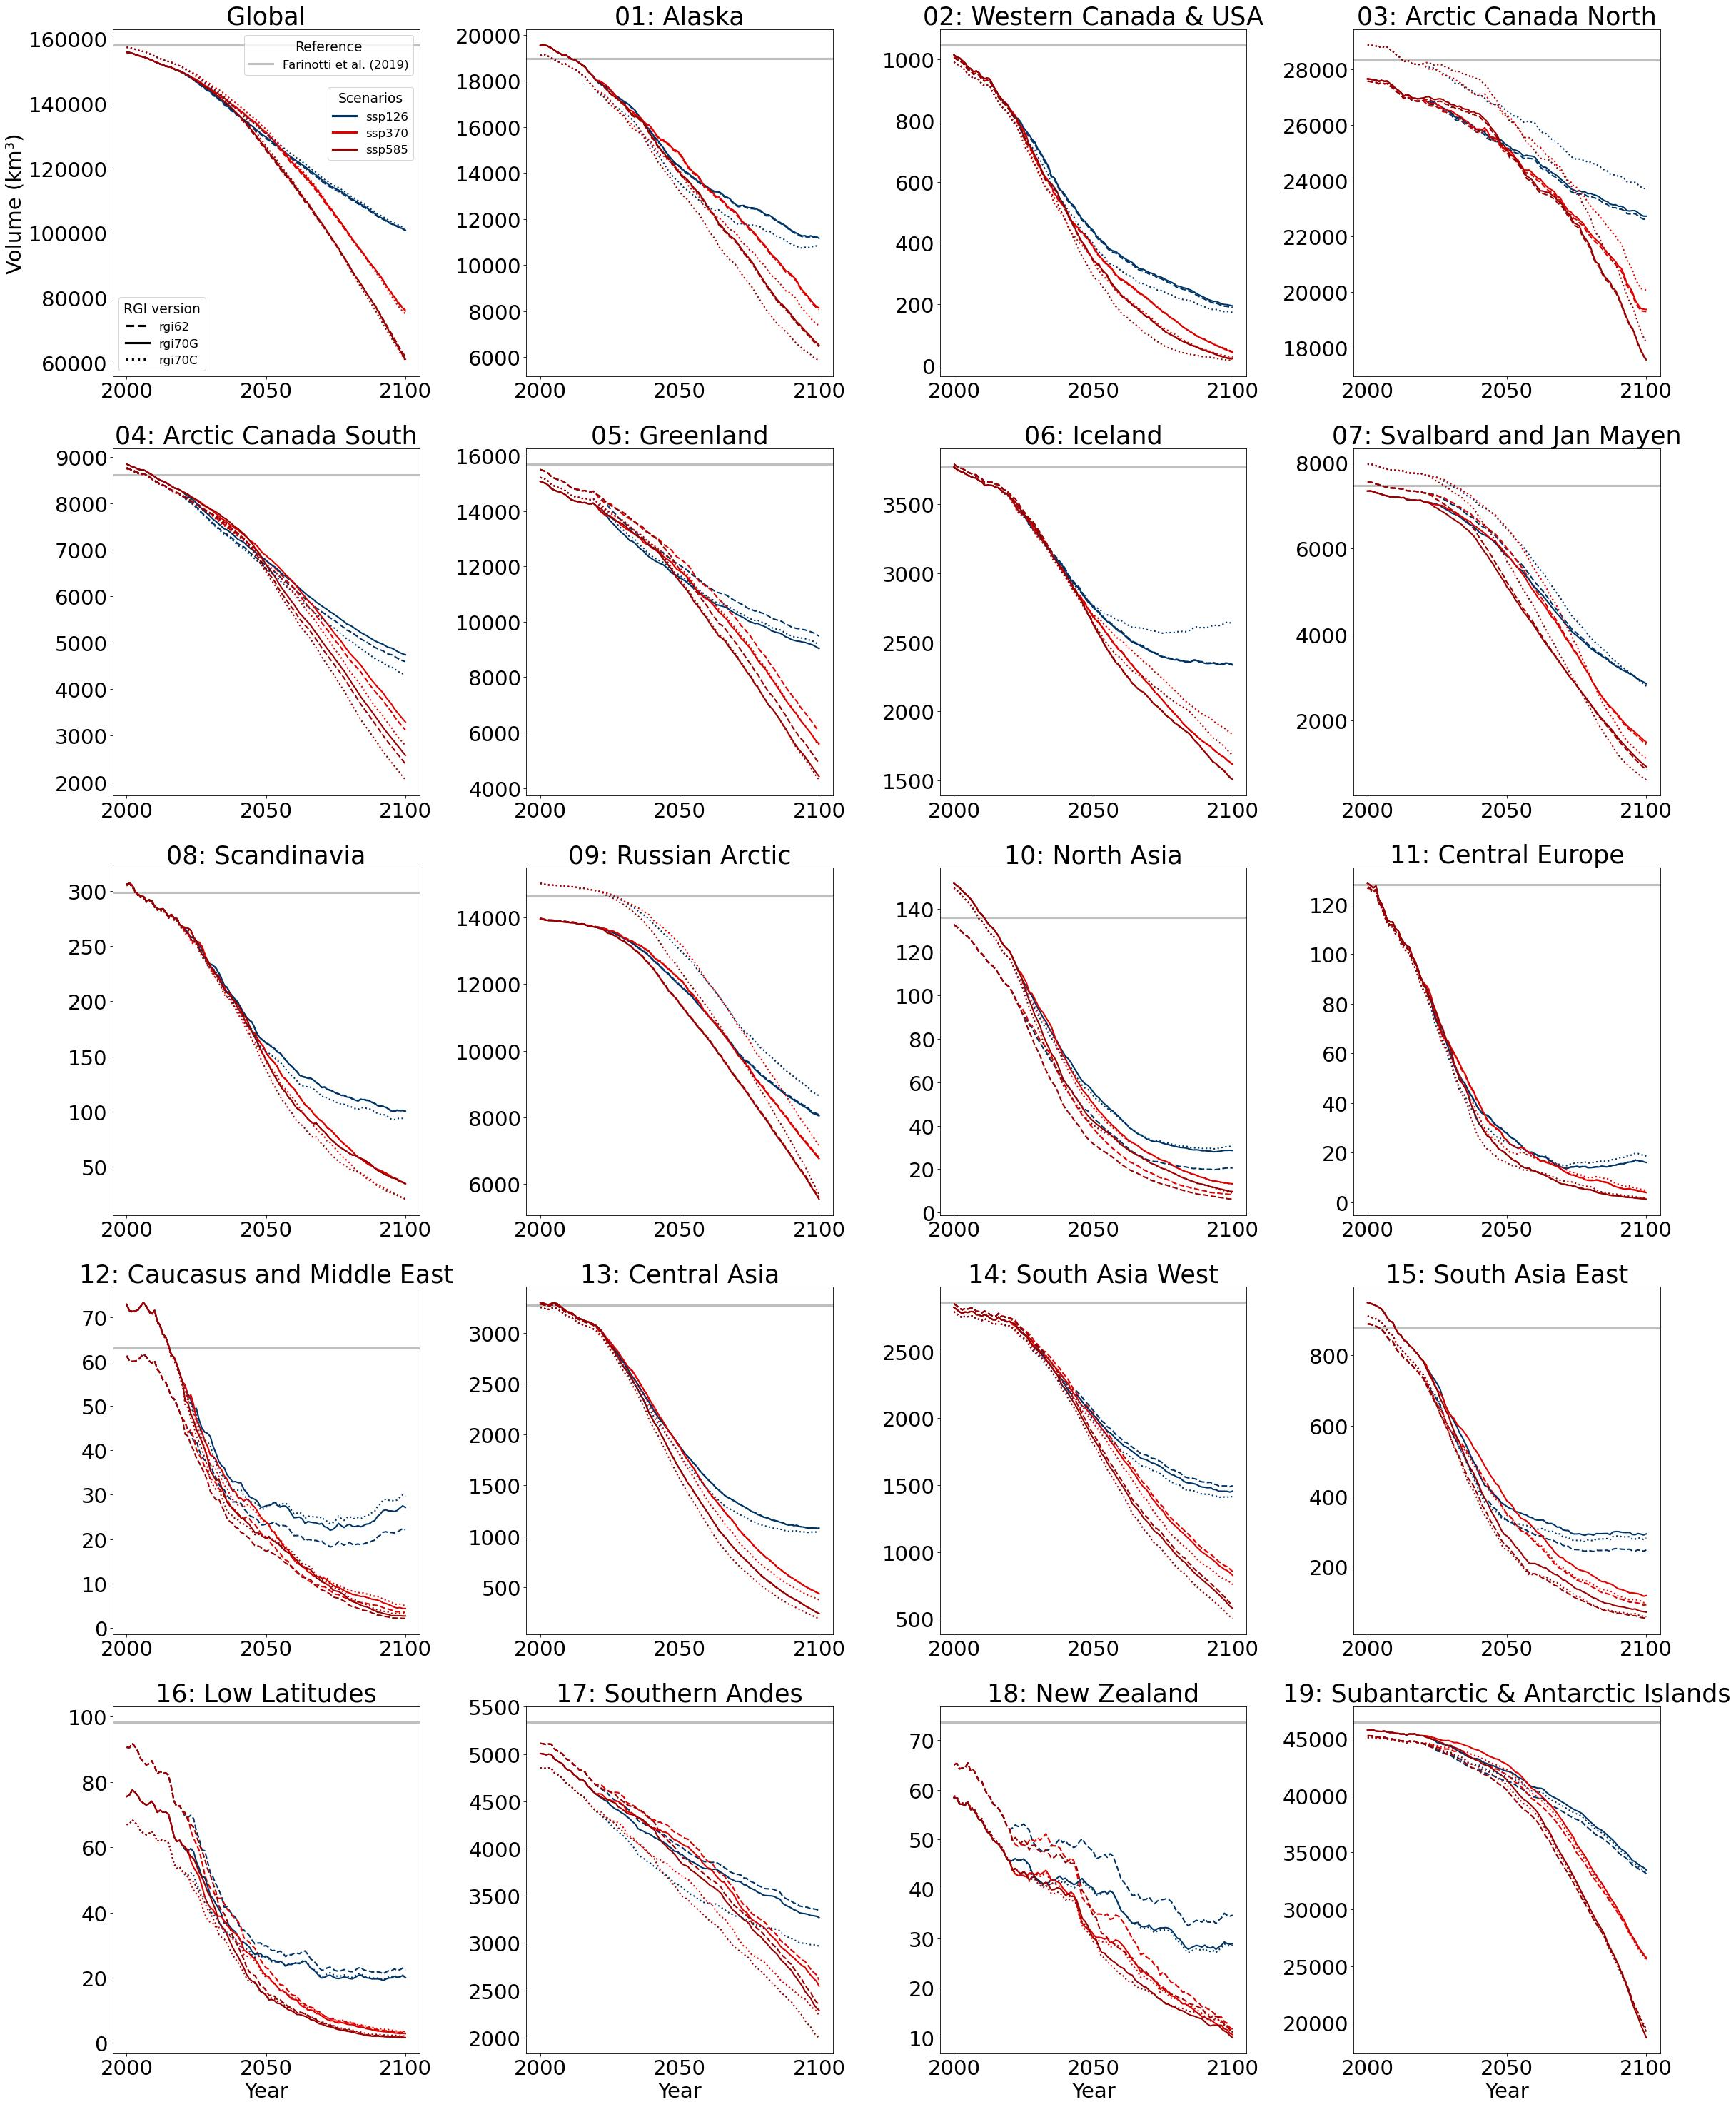

In [55]:
cmip = 'CMIP6'
plt.rc('font', size=28)
plt.figure(figsize=(32,40)) #harey=True, sharex=True)
#plt.ylabel('Volume (in % relative to 2020)')

farinotti_handle = Line2D(
    [0], [0],
    color='grey',
    lw=3,
    alpha=0.5,
    label='Farinotti et al. (2019)'
)


for j,r in enumerate(['Global', 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16,17, 18,19 ]):
    plt.subplot(5,4,j+1)
    ax = plt.gca()
    for rgi_version in rgi_versions: 
        end_year= 2100
        df_meta = pd.read_csv(f'{path}/common_running_2100/metadata_{rgi_version}{add}.csv')
        df_meta.loc[df_meta.end_year==2101,'end_year'] = 2100

        scenario_list = list(df_meta.loc[(df_meta.cmip==cmip) & (df_meta.end_year==end_year)].scenario.unique())
        scenario_list.sort()
        if r == 'Global':
            rgi_reg = r
            if rgi_version == 'rgi62':
                ax.set_title('Global')
                ax.axhline(df_itmix.sum()['vol_itmix_m3']/1e9, color='grey', lw=3, alpha = 0.5, label='Farinotti et al. (2019)')
                rgi_reg_l = 'global'
            else: 
                rgi_reg_l = f'global_{rgi_version}'
        else:
            rgi_reg = f'{r:02}'
            if rgi_version == 'rgi70G':
                rgi_reg_l = f'RGI2000-v7.0-G-{rgi_reg}'
            elif rgi_version == 'rgi70C':
                rgi_reg_l = f'RGI2000-v7.0-C-{rgi_reg}'                
            else:
                rgi_reg_l = f'RGI{rgi_reg}'
            if rgi_version=='rgi62':
                ax.set_title(f'{rgi_reg}: {d_reg_num_name[rgi_reg]}')
                ax.axhline(df_itmix.loc[df_itmix.rgi_region == rgi_reg].sum()['vol_itmix_m3']/1e9, color='grey', lw=3, alpha = 0.5)

        #for end_year in [2100]:
        ls = ls_d[rgi_version]
        # let's only plot those scenarios that exist only until 2300
        scenario_list = list(df_meta.loc[(df_meta.cmip==cmip) & (df_meta.end_year==2100)].scenario.unique())
        scenario_list.sort()

        for scenario in scenario_list:
            idir = path + 'common_running_2100/' + f'volume/{cmip}/{end_year}/{rgi_reg_l}/'

            df = pd.read_csv(idir + f'{scenario}.csv', index_col=0)
            df_rel = df/1e9 #df.loc[2020]

            ax.plot(df.index, df_rel, lw=2, alpha = 1, color=colors_scenario[scenario],
                   ls= ls,label = f'{rgi_version}: {scenario}');
            #ax.fill_between(df.index, df_rel.min(axis=1), df_rel.max(axis=1), alpha=0.1, color=colors_scenario[scenario])
    if j in [0]: #4,8,12,16]:
        ax.set_ylabel('Volume (km³)')
    if j>=16:
        ax.set_xlabel('Year')
    if j == 0:
        leg1 = ax.legend(
            handles=scenario_handles,
            title='Scenarios',
            loc='upper right',
            bbox_to_anchor=(1,0.85),
            fontsize=16,
            title_fontsize=18
        )
    
        leg2 = ax.legend(
            handles=rgi_handles,
            title='RGI version',
            loc='lower left',
            fontsize=16,
            title_fontsize=18
        )
    
        leg3 = ax.legend(
            handles=[farinotti_handle],
            title='Reference',
            loc='upper right',
            fontsize=16,
            title_fontsize=18
        )
    
        ax.add_artist(leg1)
        ax.add_artist(leg2)

        #ax.legend(title='Scenarios & RGI versions\n(only one GCM, regional_spinup, w5e5)', #: (median, single\n& total range of GCMs)', 
        #          ncol=2, fontsize=16, title_fontsize=18, loc = 'lower left');
    #ax.set_ylim([-1,145])
plt.tight_layout()
plt.savefig('regional_glacier_volume_until2100_absolute_comparison_rgi6_vs_7_only_one_gcm.png')

## B. Comparing projections of different versions and options

rgi62 per_glacier_spinup w5e5
rgi62 per_glacier_spinup era5


FileNotFoundError: [Errno 2] No such file or directory: '/home/www/oggm/oggm-standard-projections/oggm-standard-projections-csv-files/1.6.3/era5/per_glacier_spinup/common_running_2100/metadata.csv'

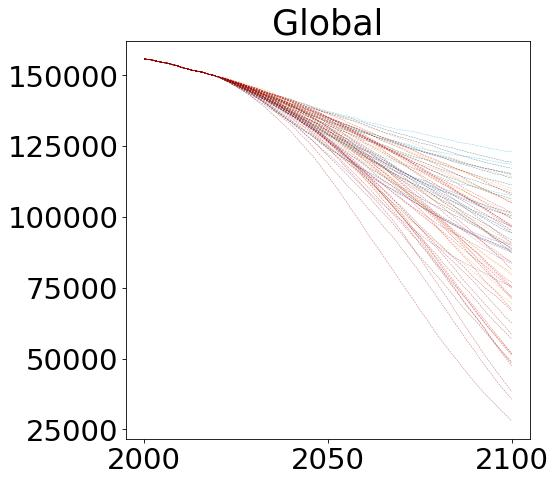

In [11]:
# change this path to your local path 
cmip = 'CMIP6'
end_year= 2100

_path = '/home/www/oggm/oggm-standard-projections/oggm-standard-projections-csv-files/1.6.3/'
options = [# 'oggm_v1.6.1-rgi62-per_glacier_spinup-w5e5', 
            # maybe that one is not really necessary as we have shown in 1.6.3/analyse_csv_files_1.6.3.ipynb
            # that the two versions result in very similar glacier projections
           'oggm_v1.6.3-rgi62-per_glacier_spinup-w5e5',
           'oggm_v1.6.3-rgi62-per_glacier_spinup-era5',
           'oggm_v1.6.3-rgi62-regional_spinup-w5e5',
           'oggm_v1.6.3-rgi70-regional_spinup-w5e5']


plt.rc('font', size=28)
plt.figure(figsize=(32,40))

for j,r in enumerate(['Global', 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17, 18,19]): 
    plt.subplot(5,4,j+1)
    ax = plt.gca()
    for option in options:
        _,rgi_version, exp, baseline_climate = option.split('-')
        print(rgi_version, exp, baseline_climate)
        path = _path + f'{baseline_climate}/{exp}/'
        if exp != 'regional_spinup':
            df_meta = pd.read_csv(f'{path}common_running_2100/metadata.csv')
        else:
            df_meta = pd.read_csv(f'{path}common_running_2100/metadata_{rgi_version}{add}.csv')
        df_meta.loc[df_meta.end_year==2101,'end_year'] = 2100

        scenario_list = list(df_meta.loc[(df_meta.cmip==cmip) & (df_meta.end_year==end_year)].scenario.unique())
        scenario_list.sort()
        if r == 'Global':
            rgi_reg = r
            rgi_reg_l = 'global'
            ax.set_title('Global')
        else:
            rgi_reg = f'{r:02}'
            if rgi_version == 'rgi70':
                rgi_reg_l = f'RGI2000-v7.0-G-{rgi_reg}'
            else:
                rgi_reg_l = f'RGI{rgi_reg}'
            if rgi_version=='rgi62':
                ax.set_title(f'{rgi_reg}: {d_reg_num_name[rgi_reg]}')
        
        #for end_year in [2100]:
        ls = ls_d[rgi_version]
        # let's only plot those scenarios that exist only until 2300
        scenario_list = list(df_meta.loc[(df_meta.cmip==cmip) & (df_meta.end_year==2100)].scenario.unique())
        scenario_list.sort()

        for scenario in scenario_list:
            idir = path + 'common_running_2100/' + f'volume/{cmip}/{end_year}/{rgi_reg_l}/'

            df = pd.read_csv(idir + f'{scenario}.csv', index_col=0)
            df_rel = df/1e9 #df.loc[2020]

            ax.plot(df.index, df_rel, lw=0.5, alpha = 0.5, color=colors_scenario[scenario],
                   ls= ls, label=f'{rgi_version}, {exp}, {baseline_climate}');
    if j in [0]: #4,8,12,16]:
        ax.set_ylabel('Volume (km³)')
    if j>=16:
        ax.set_xlabel('Year')
    if j == 0:
        ax.legend(title='Scenarios & RGI versions\n(only one GCM)', #: (median, single\n& total range of GCMs)', 
                  ncol=2, fontsize=16, title_fontsize=18, loc = 'lower left');
    #ax.set_ylim([-1,145])
plt.tight_layout()
plt.savefig('regional_glacier_volume_until2100_absolute_comparison_all_options_only_one_gcm.png')

In [ ]:
color_d = {'rgi70 regional spinup':'C0', 'rgi62 regional spinup':'C1',
        'Standard projections\nOGGMv161 rgi62 per-glacier': 'C2',
         'Standard projections\nOGGMv163 rgi62 per-glacier':'C3',
         'OGGMv163 rgi62 per-glacier\n(ERA5 instead of W5E5)': 'C4' }


**What next?**
- if you are interested in a comparison to Rounce et al. (2023), you can check out [this jupyter notebook](https://nbviewer.org/urls/cluster.klima.uni-bremen.de/~oggm/oggm-standard-projections/oggm-standard-projections-csv-files/notebooks/compare_oggm_1.6.1_to_rounce_et_al_2023.ipynb?flush_cache=true) where we compared explicitly the common running glaciers of OGGM v1.6.1 to Rounce et al. (2023)
- if you want to compare the OGGM standard projections v1.6.3 to OGGM v1.6.1 or if you just want to see all GCMs for OGGM v1.6.3, check out [this notebook](analyse_csv_files_1.6.3.ipynb)
- some example analysis of the raw oggm per-glacier files (together with for example runoff analysis) is in [this notebook](https://nbviewer.org/urls/cluster.klima.uni-bremen.de/~oggm/oggm-standard-projections/analysis_notebooks/workflow_to_analyse_per_glacier_projection_files.ipynb?flush_cache=true)